In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print("\nChurn rate:")
print((df['Churn'].value_counts(normalize=True) * 100).round(1))

Shape: (7043, 21)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate:
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges:", df['TotalCharges'].isnull().sum())

df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

df['TotalCharges'] = df['TotalCharges'].fillna(0)
df.drop(columns=['customerID'], inplace=True)
print("Cleaned shape:", df.shape)


Missing TotalCharges: 11
Cleaned shape: (7043, 20)


In [14]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after encoding: (7043, 31)


In [15]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

Train shape: (5634, 30)
Test shape: (1409, 30)
Train churn rate: 0.265
Test churn rate: 0.265


In [16]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Scaling done")

Scaling done


In [17]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_balanced.value_counts().to_dict())

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
}

results = []

for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs)
    })

results_df = pd.DataFrame(results).round(3)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall    F1  ROC-AUC
Logistic Regression     0.738      0.505   0.711 0.590    0.819
      Random Forest     0.760      0.542   0.626 0.581    0.817
            XGBoost     0.747      0.520   0.620 0.566    0.799


In [19]:
best_model_name = 'Logistic Regression'
best_model = models[best_model_name]

print(f"Selected model: {best_model_name}")
print(f"Reasoning: Highest ROC-AUC (0.819) and highest Recall (0.711) — ")
print(f"prioritizing catching actual churners over raw accuracy, since ")
print(f"missing a churner is costlier than a wasted retention offer.")

Selected model: Logistic Regression
Reasoning: Highest ROC-AUC (0.819) and highest Recall (0.711) — 
prioritizing catching actual churners over raw accuracy, since 
missing a churner is costlier than a wasted retention offer.


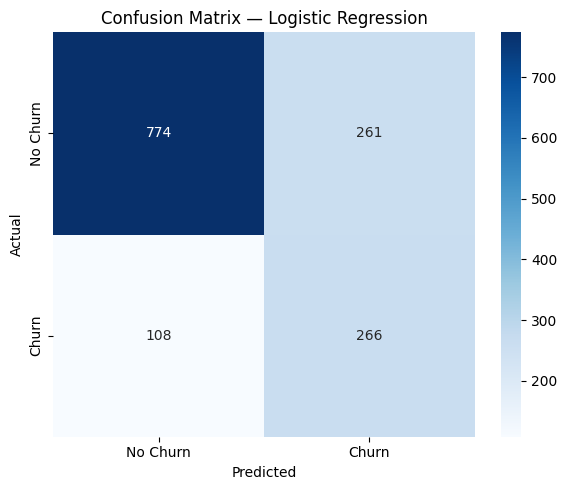

              precision    recall  f1-score   support

    No Churn       0.88      0.75      0.81      1035
       Churn       0.50      0.71      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409



In [20]:
from sklearn.metrics import confusion_matrix, classification_report

preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('assets/confusion_matrix.png')
plt.show()

print(classification_report(y_test, preds, target_names=['No Churn', 'Churn']))

In [21]:
import os

os.makedirs('assets', exist_ok=True)
os.makedirs('models', exist_ok=True)

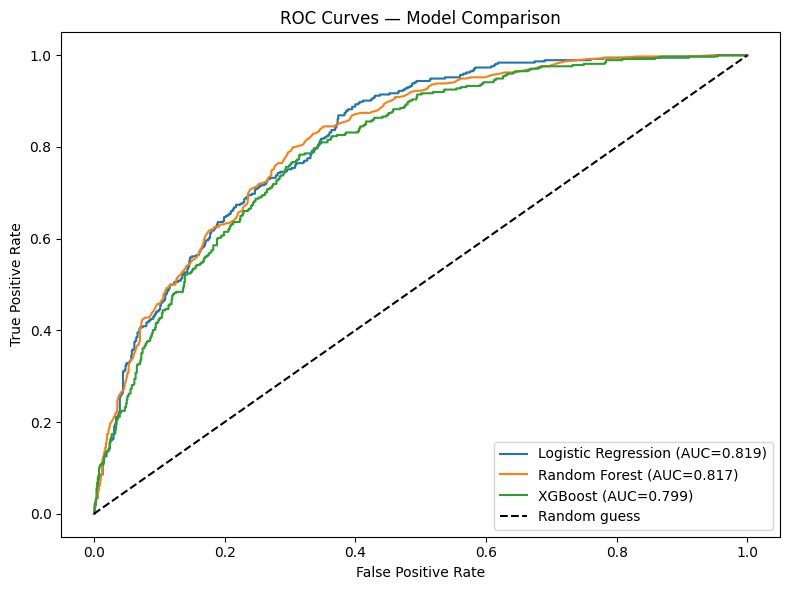

In [22]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('assets/roc_comparison.png')
plt.show()

In [23]:
import pickle, os
os.makedirs('models', exist_ok=True)
os.makedirs('assets', exist_ok=True)

with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

X_train.columns.to_series().to_csv('models/feature_columns.csv', index=False)
results_df.to_csv('assets/model_comparison_results.csv', index=False)

print("Saved model, scaler, feature columns, and results")

Saved model, scaler, feature columns, and results


In [ ]:
best_model_name = 'Logistic Regression'
best_model = models[best_model_name]

print(f"Selected model: {best_model_name}")
print(f"Reasoning: Highest ROC-AUC (0.819) and highest Recall (0.711) — ")
print(f"prioritizing catching actual churners over raw accuracy, since ")
print(f"missing a churner is costlier than a wasted retention offer.")

Selected model: Logistic Regression
Reasoning: Highest ROC-AUC (0.819) and highest Recall (0.711) — 
prioritizing catching actual churners over raw accuracy, since 
missing a churner is costlier than a wasted retention offer.
